# Portfolio Piece: Neural Network From Scratch in PyTorch
In this notebook we aim to Build and train a small neural network (MLP) from scratch, then run controlled experiments to see how **depth (layers)**, **activation functions**, and **learning rate** affect learning.

**Why this topic:**


This project connects directly to core course concepts in optimization and representation learning. Neural networks learn by gradient descent, where weights are iteratively updated to minimize a loss function. I chose to vary architectural choices (number of layers) and hyperparameters (activation functions and learning rate) to observe how these design decisions impact learning dynamics and model performance.
Loss curves and accuracy metrics are used to visualize how gradient descent behaves under different settings, helping explain both convergence and generalization. This demonstrates a conceptual understanding of how model structure and training parameters influence performance, as discussed throughout the course.

**Datasets used**
1. **XOR** (toy dataset): proves why non-linear models are needed.
2. **Digits (scikit-learn)**: small MNIST-like dataset (8×8 images) for real multi-class classification.

---
## Running the notebook
1. Run cells top-to-bottom.

In [1]:
import math
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## 1) Model: a simple MLP builder
This is a “from scratch” multi-layer perceptron using `nn.Linear` layers, a chosen activation, and a final linear output layer.

In [2]:
def get_activation(name: str) -> nn.Module:
    name = name.lower().strip()
    if name == "relu":
        return nn.ReLU()
    if name == "tanh":
        return nn.Tanh()
    if name == "sigmoid":
        return nn.Sigmoid()
    if name == "leakyrelu":
        return nn.LeakyReLU(0.1)
    raise ValueError(f"Unknown activation: {name}")

class MLP(nn.Module):
    def __init__(self, input_dim: int, hidden_dims: list, output_dim: int, activation: str = "relu"):
        super().__init__()
        act = get_activation(activation)
        
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            layers.append(act)
            prev = h
        layers.append(nn.Linear(prev, output_dim))
        
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

## 2) Helper functions: training + accuracy
- **CrossEntropyLoss** for classification (includes softmax inside)
- We track **loss per epoch** to visualize gradient descent.

In [3]:
def train_classifier(model: nn.Module,
                     X: torch.Tensor,
                     y: torch.Tensor,
                     epochs: int = 2000,
                     lr: float = 0.1,
                     optimizer_name: str = "adam",
                     weight_decay: float = 0.0):
    model = model.to(device)
    X = X.to(device)
    y = y.to(device)

    criterion = nn.CrossEntropyLoss()

    if optimizer_name.lower() == "sgd":
        optimizer = optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name.lower() == "adam":
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        raise ValueError("optimizer_name must be 'sgd' or 'adam'")

    losses = []
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        logits = model(X)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    return losses

@torch.no_grad()
def accuracy(model: nn.Module, X: torch.Tensor, y: torch.Tensor) -> float:
    model.eval()
    X = X.to(device)
    y = y.to(device)
    logits = model(X)
    preds = logits.argmax(dim=1)
    return (preds == y).float().mean().item()

## 3) Task A — XOR classification
XOR is not linearly separable. A neural network needs a **non-linear activation** and at least one hidden layer to solve it.

In [4]:
# XOR dataset
X_xor = torch.tensor([[0., 0.],
                      [0., 1.],
                      [1., 0.],
                      [1., 1.]], dtype=torch.float32)
y_xor = torch.tensor([0, 1, 1, 0], dtype=torch.long)

X_xor, y_xor

(tensor([[0., 0.],
         [0., 1.],
         [1., 0.],
         [1., 1.]]),
 tensor([0, 1, 1, 0]))

### Baseline XOR model (1 hidden layer)

Final XOR accuracy: 1.0


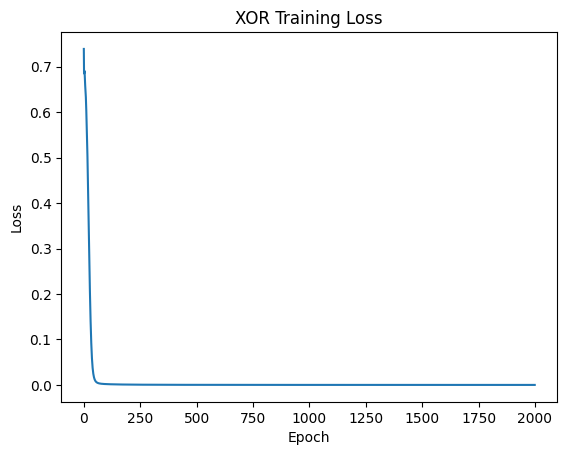

In [5]:
model = MLP(input_dim=2, hidden_dims=[8], output_dim=2, activation="tanh")
losses = train_classifier(model, X_xor, y_xor, epochs=2000, lr=0.05, optimizer_name="adam")

print("Final XOR accuracy:", accuracy(model, X_xor, y_xor))

plt.figure()
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("XOR Training Loss")
plt.show()

### Experiments on XOR
We vary:
- **Depth:** 1 vs 2 vs 3 hidden layers
- **Activation:** tanh / relu / sigmoid
- **Learning rate:** smaller vs larger

We compare final **training accuracy** and look at **loss curves**.

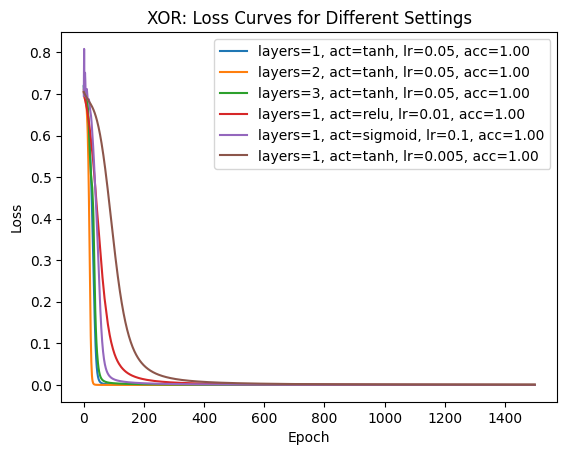

{'hidden_dims': [4], 'activation': 'tanh', 'lr': 0.05} -> acc: 1.0 final_loss: 0.0
{'hidden_dims': [4, 4], 'activation': 'tanh', 'lr': 0.05} -> acc: 1.0 final_loss: 0.0
{'hidden_dims': [4, 4, 4], 'activation': 'tanh', 'lr': 0.05} -> acc: 1.0 final_loss: 0.0001
{'hidden_dims': [8], 'activation': 'relu', 'lr': 0.01} -> acc: 1.0 final_loss: 0.0002
{'hidden_dims': [8], 'activation': 'sigmoid', 'lr': 0.1} -> acc: 1.0 final_loss: 0.0001
{'hidden_dims': [8], 'activation': 'tanh', 'lr': 0.005} -> acc: 1.0 final_loss: 0.0004


In [6]:
def run_xor_experiment(hidden_dims, activation, lr, epochs=1500):
    m = MLP(input_dim=2, hidden_dims=hidden_dims, output_dim=2, activation=activation)
    losses = train_classifier(m, X_xor, y_xor, epochs=epochs, lr=lr, optimizer_name="adam")
    acc = accuracy(m, X_xor, y_xor)
    return losses, acc

configs = [
    {"hidden_dims":[4],        "activation":"tanh",   "lr":0.05},
    {"hidden_dims":[4,4],      "activation":"tanh",   "lr":0.05},
    {"hidden_dims":[4,4,4],    "activation":"tanh",   "lr":0.05},
    {"hidden_dims":[8],        "activation":"relu",   "lr":0.01},
    {"hidden_dims":[8],        "activation":"sigmoid","lr":0.1},
    {"hidden_dims":[8],        "activation":"tanh",   "lr":0.005},
]

results = []
for cfg in configs:
    losses, acc = run_xor_experiment(cfg["hidden_dims"], cfg["activation"], cfg["lr"], epochs=1500)
    results.append((cfg, losses, acc))

# Plot loss curves
plt.figure()
for cfg, losses, acc in results:
    label = f"layers={len(cfg['hidden_dims'])}, act={cfg['activation']}, lr={cfg['lr']}, acc={acc:.2f}"
    plt.plot(losses, label=label)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("XOR: Loss Curves for Different Settings")
plt.legend()
plt.show()

# Print summary
for cfg, losses, acc in results:
    print(cfg, "-> acc:", round(acc, 3), "final_loss:", round(losses[-1], 4))

### Quick interpretation (XOR)
- If loss decreases smoothly to near-zero and accuracy → 1.00, gradient descent is working.
- **Too high LR** can make loss oscillate or get stuck.
- **Sigmoid** can learn but may be slower/saturate over time; **tanh** is often strong for XOR.

## 4) Task B — Digits classification (MNIST-like)
We use `sklearn.datasets.load_digits` (8×8 grayscale digits).
Steps:
1. Train/test split
2. Standardize features (helps MLP training)
3. Train with mini-batches

In [7]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

digits = load_digits()
X = digits.data.astype(np.float32)  # shape: (n_samples, 64)
y = digits.target.astype(np.int64)  # 0-9

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed, stratify=y)

# Standardize features (important for MLP training)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_test  = scaler.transform(X_test).astype(np.float32)

X_train_t = torch.tensor(X_train)
y_train_t = torch.tensor(y_train)
X_test_t  = torch.tensor(X_test)
y_test_t  = torch.tensor(y_test)

X_train_t.shape, y_train_t.shape

(torch.Size([1437, 64]), torch.Size([1437]))

### Mini-batch training loop (Digits)

In [8]:
from torch.utils.data import TensorDataset, DataLoader

def train_digits(model: nn.Module,
                 X_train: torch.Tensor,
                 y_train: torch.Tensor,
                 X_test: torch.Tensor,
                 y_test: torch.Tensor,
                 epochs: int = 20,
                 lr: float = 1e-3,
                 batch_size: int = 64,
                 optimizer_name: str = "adam"):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()

    if optimizer_name.lower() == "sgd":
        optimizer = optim.SGD(model.parameters(), lr=lr)
    elif optimizer_name.lower() == "adam":
        optimizer = optim.Adam(model.parameters(), lr=lr)
    else:
        raise ValueError("optimizer_name must be 'sgd' or 'adam'")

    train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)

    train_losses = []
    test_accs = []

    for epoch in range(epochs):
        model.train()
        running = 0.0
        n = 0
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            running += loss.item() * xb.size(0)
            n += xb.size(0)

        train_losses.append(running / n)
        test_accs.append(accuracy(model, X_test, y_test))

    return train_losses, test_accs

### Baseline Digits model + loss/accuracy curves

Final test accuracy: 0.9750000238418579


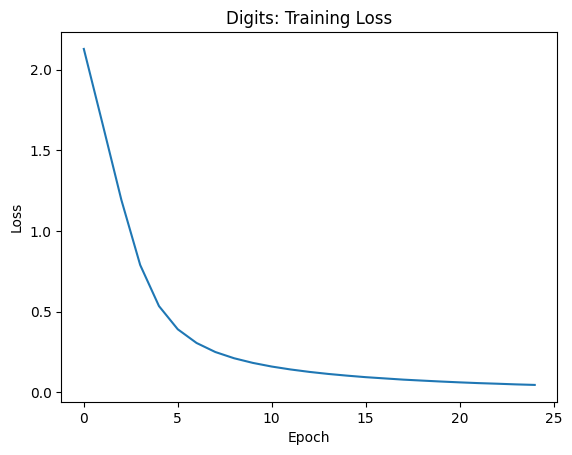

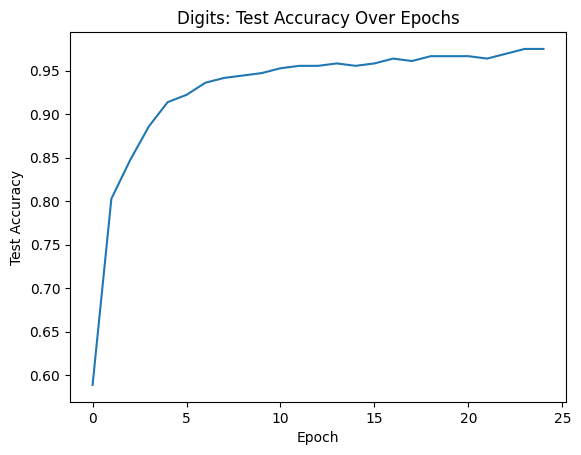

In [9]:
digits_model = MLP(input_dim=64, hidden_dims=[64], output_dim=10, activation="relu")
train_losses, test_accs = train_digits(
    digits_model,
    X_train_t, y_train_t, X_test_t, y_test_t,
    epochs=25, lr=1e-3, batch_size=64, optimizer_name="adam"
)

print("Final test accuracy:", test_accs[-1])

plt.figure()
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Digits: Training Loss")
plt.show()

plt.figure()
plt.plot(test_accs)
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Digits: Test Accuracy Over Epochs")
plt.show()

### Experiments on Digits
We test how performance changes when we:
- Add layers (depth)
- Switch activations
- Change learning rate

We summarize results in a table and then look at the best run’s confusion matrix.

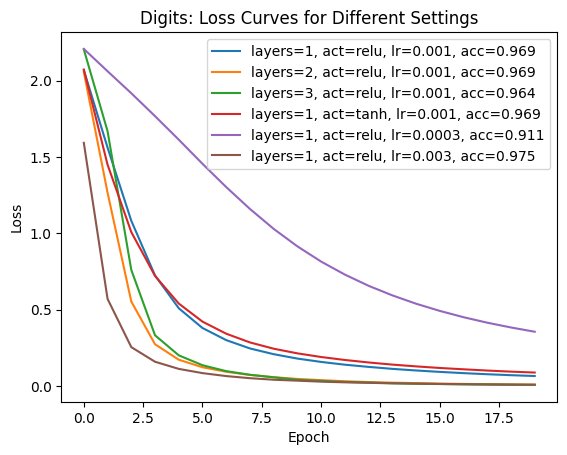

,hidden_dims,n_layers,activation,lr,final_loss,final_test_acc
5,[64],1,relu,0.0030,0.008431,0.975000
0,[64],1,relu,0.0010,0.065277,0.969444
1,"[128, 64]",2,relu,0.0010,0.008940,0.969444
3,[64],1,tanh,0.0010,0.088080,0.969444
2,"[128, 64, 32]",3,relu,0.0010,0.007059,0.963889
4,[64],1,relu,0.0003,0.355372,0.911111


In [10]:
exp_cfgs = [
    {"hidden_dims":[64],           "activation":"relu",  "lr":1e-3},
    {"hidden_dims":[128, 64],      "activation":"relu",  "lr":1e-3},
    {"hidden_dims":[128, 64, 32],  "activation":"relu",  "lr":1e-3},
    {"hidden_dims":[64],           "activation":"tanh",  "lr":1e-3},
    {"hidden_dims":[64],           "activation":"relu",  "lr":3e-4},
    {"hidden_dims":[64],           "activation":"relu",  "lr":3e-3},
]

all_runs = []
for cfg in exp_cfgs:
    m = MLP(input_dim=64, hidden_dims=cfg["hidden_dims"], output_dim=10, activation=cfg["activation"])
    losses, accs = train_digits(
        m, X_train_t, y_train_t, X_test_t, y_test_t,
        epochs=20, lr=cfg["lr"], batch_size=64, optimizer_name="adam"
    )
    all_runs.append((cfg, m, losses, accs))

# Plot loss curves
plt.figure()
for cfg, m, losses, accs in all_runs:
    label = f"layers={len(cfg['hidden_dims'])}, act={cfg['activation']}, lr={cfg['lr']}, acc={accs[-1]:.3f}"
    plt.plot(losses, label=label)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Digits: Loss Curves for Different Settings")
plt.legend()
plt.show()

# Summarize results
rows = []
for cfg, m, losses, accs in all_runs:
    rows.append({
        "hidden_dims": str(cfg["hidden_dims"]),
        "n_layers": len(cfg["hidden_dims"]),
        "activation": cfg["activation"],
        "lr": cfg["lr"],
        "final_loss": float(losses[-1]),
        "final_test_acc": float(accs[-1]),
    })
results_df = pd.DataFrame(rows).sort_values("final_test_acc", ascending=False)
results_df

### Best model: confusion matrix (what digits it confuses)

Best config: {'hidden_dims': [64], 'activation': 'relu', 'lr': 0.003} final_acc: 0.9750000238418579


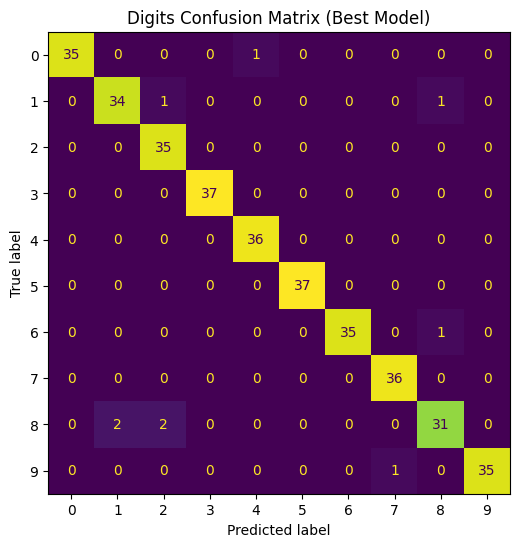

In [11]:
best_cfg, best_model, best_losses, best_accs = sorted(all_runs, key=lambda x: x[3][-1], reverse=True)[0]
print("Best config:", best_cfg, "final_acc:", best_accs[-1])

# Predictions
best_model.eval()
with torch.no_grad():
    logits = best_model(X_test_t.to(device))
    preds = logits.argmax(dim=1).cpu().numpy()

cm = confusion_matrix(y_test, preds, labels=list(range(10)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, colorbar=False)
plt.title("Digits Confusion Matrix (Best Model)")
plt.show()

## 5) Training set size vs performance
To connect model behavior to data availability, we train the same model on **smaller subsets** of the training set.

**Expectation:** with less data, accuracy drops and results become less stable.

In [12]:
def train_with_subset(n_train, cfg):
    # Subsample training data
    idx = np.random.RandomState(seed).choice(len(X_train), size=n_train, replace=False)
    X_sub = torch.tensor(X_train[idx]).float()
    y_sub = torch.tensor(y_train[idx]).long()

    m = MLP(input_dim=64, hidden_dims=cfg["hidden_dims"], output_dim=10, activation=cfg["activation"])
    losses, accs = train_digits(
        m, X_sub, y_sub, X_test_t, y_test_t,
        epochs=15, lr=cfg["lr"], batch_size=64, optimizer_name="adam"
    )
    return accs[-1]

probe_cfg = {"hidden_dims":[128, 64], "activation":"relu", "lr":1e-3}
sizes = [200, 500, 1000, len(X_train)]
accs = [train_with_subset(s, probe_cfg) for s in sizes]

pd.DataFrame({"train_size": sizes, "final_test_acc": accs})

,train_size,final_test_acc
0,200,0.827778
1,500,0.952778
2,1000,0.975000
3,1437,0.975000


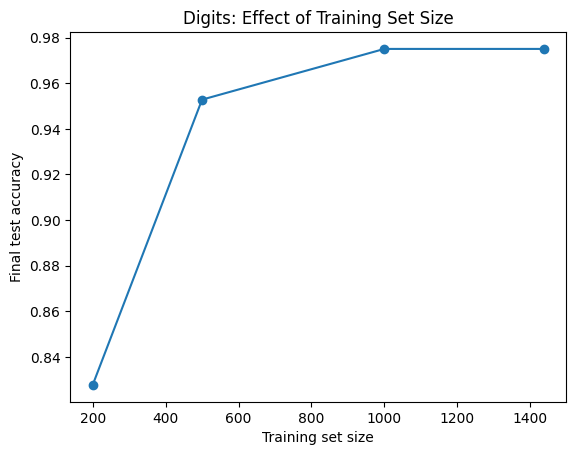

In [13]:
plt.figure()
plt.plot(sizes, accs, marker="o")
plt.xlabel("Training set size")
plt.ylabel("Final test accuracy")
plt.title("Digits: Effect of Training Set Size")
plt.show()

## 6) Analysis:
- **Depth:** Adding layers can help up to a point, but it can also make optimization harder and increase overfitting risk.
- **Activation:** ReLU often trains fast on Digits; tanh can work but may train slower.
- **Learning rate:** Too small → slow learning; too large → unstable loss curves.
- **Data size:** More data generally improves accuracy and stability.

### Limitations
- Digits is small (8×8) compared to real MNIST; results may not transfer directly to larger datasets.
- We used a simple MLP; CNNs are usually better for image tasks.
- No systematic hyperparameter search (we only tried a small grid).

### Future steps
- Add validation split + early stopping
- Try dropout / weight decay
- Compare against a simple baseline (logistic regression) for context
- Try MNIST (28×28) or Fashion-MNIST